# TP: Patch-Based Texture synthesis

Read, understand, and complete the following notebook. The goal of this session is to implement the method described in the paper [Image Quilting for Texture Synthesis and Transfer](http://graphics.cs.cmu.edu/people/efros/research/quilting/quilting.pdf) by Efros and Freeman.

- You must return the completed notebook, including your answers and code output in a PDF file.

- You may need to add cells to write your code and comments.

- Upload your notebook on EducNet as a **PDF file** using the format '**triva_tp1_yourname.pdf**'. I use the command:

*jupyter nbconvert --to html notebook.ipynb*  

to convert a notebook to pdf.

- Do not spend more than 5 hours!


## 0. Look at the paper
Check the figures of the paper linked above, in particular Figure 2. The general idea is actually quite simple (but powerful).
A look at this [gif](https://en.wikipedia.org/wiki/Texture_synthesis#/media/File:Imagequilting.gif) from Wikipedia is also very useful.

##1. Getting started

###1.1 Libraries

Let's first import the libraries we will need:

In [175]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

###1.2 Downloading and visualizing images


`!wget` lets you upload files on the directory used by Colab. We will use it to download 3 images of textures:

In [176]:
!wget https://vincentlepetit.github.io/files/lectures/triva/gauze2.png -O gauze2.png
!ls

--2026-03-17 23:43:42--  https://vincentlepetit.github.io/files/lectures/triva/gauze2.png
Resolving vincentlepetit.github.io (vincentlepetit.github.io)... 185.199.109.153, 185.199.110.153, 185.199.111.153, ...
Connecting to vincentlepetit.github.io (vincentlepetit.github.io)|185.199.109.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22439 (22K) [image/png]
Saving to: ‘gauze2.png’

gauze2.png          100%[===================>]  21.91K  --.-KB/s    in 0.003s  

2026-03-17 23:43:42 (6.75 MB/s) - ‘gauze2.png’ saved [22439/22439]

220                             montparnasse.png.14
Triva Texture Synthesis 4.ipynb montparnasse.png.2
__pycache__                     montparnasse.png.3
bricks.png                      montparnasse.png.4
chocolate.png                   montparnasse.png.5
crackers.png                    montparnasse.png.6
gauze2.png                      montparnasse.png.7
montparnasse.png                montparnasse.png.8
montparnasse.png.1         

It is now possible to download an image as a `numpy` array using:

In [177]:
texture1 = np.array(imageio.imread('gauze2.png'))

/var/folders/ch/n84hhlsn521bgb9s7cbmp3jw0000gn/T/ipykernel_3760/3119845613.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  texture1 = np.array(imageio.imread('gauze2.png'))


Using Python, can you tell the resolution of `gauze2.png`?

In [178]:
h, w, _ = texture1.shape
print("hauteur :", h)
print("largeur :", w)

hauteur : 192
largeur : 192


We can visualize an image using:

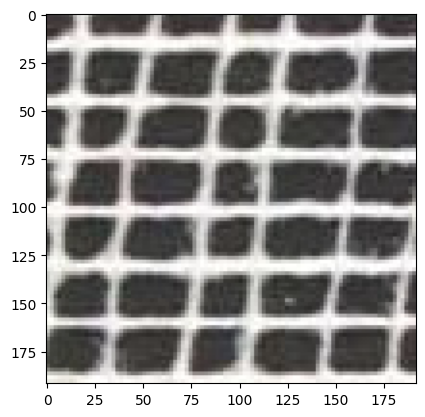

In [179]:
plt.imshow(texture1)

##2. Texture Synthesis
###2.1 Fast Prototyping: Initialization

Write the code to create an empty (black) image called `canvas` of resolution 500x500 and visualize it. It should have 3 channels and the type of the elements should be `np.uint8` (why?).

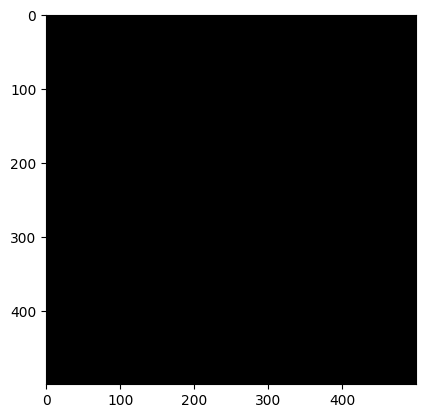

In [180]:
canvas = np.zeros((500, 500, 3), dtype = np.uint8)
#les images standards utilisent des valeurs entre 0 et 255 par canaux, et uint8 signifie unsigned (pas de valeurs négatives), 8 bits donc une plage entre 0 et 255. C'est le format standard 
plt.imshow(canvas)

Crop the patch of size 64x64 in the top-left corner of `texture1` and store the result in an image called `patch`. Hint: It can be done in 1 line of Python (remember that the images are represented here as `numpy` arrays, and all the operations on `numpy` arrays can be used).
Visualize the result.

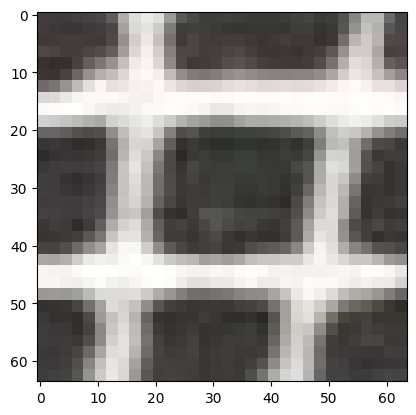

In [181]:
patch = texture1[0:64, 0:64, :]
plt.imshow(patch)
#On observe un motif répétitif en forme de grille

Copy `patch` at the top-left corner of image `canvas`. Hint: It can be done in 1 line of Python as well.
Visualize the result.

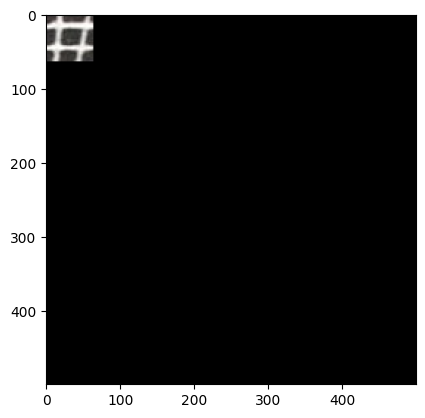

In [182]:
canvas[0:64, 0:64, :]=patch
plt.imshow(canvas)

We will need to keep track of the pixels we already assign with a value. Create a `canvas_mask` image, the same size as `canvas`, with 1 for the pixels that already have a color assigned in `canvas`, and 0 for the other pixels.

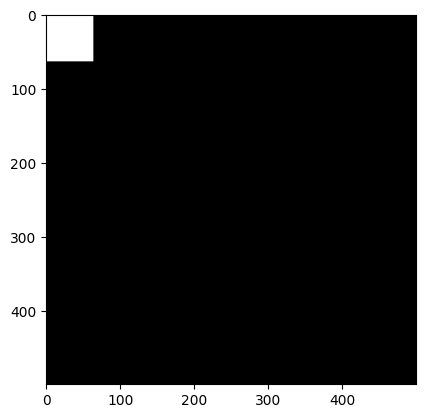

In [183]:
canvas_mask = np.zeros((500, 500), dtype=np.uint8)
canvas_mask[0:64, 0:64] = 1
plt.imshow(canvas_mask, cmap="gray")

###2.2 Fast Prototyping: Computing Similarity between Image Patches
Let's now look for a patch that overlaps well with this first patch (see Fig 2.b of the paper).

In Python, it will be convenient to first build a `numpy` array of all the possible patches that can be extracted from `texture1`.

Let's call this array `patches`. The dimensions of `patches` should be:
N x 64 x 64 x 3,
where N is the total number of patches that can be extracted from `texture1`.

How can you compute N?  Note it depends on the resolution of `texture1` and the patch size (64 here).

Write the code to build the `patches` array.

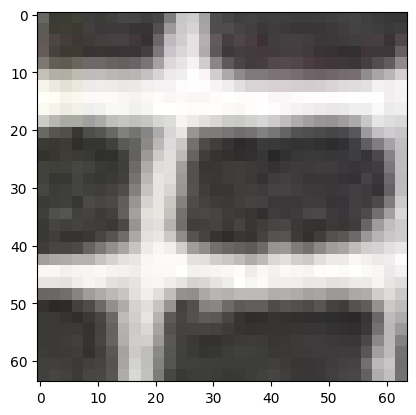

In [184]:
# On peut placer le coin haut-gauche du patch à toute position (i,j)
# telle que le patch reste dans l'image : i va de 0 à H-64, j de 0 à W-64
# Donc (H - 64 + 1) positions en hauteur et (W - 64 + 1) en largeur
patch_size = 64
Wt, Ht, Ct = texture1.shape #là Wt et Ht sont sensé être dans l'autre sens (d'après l'output de .shape() qui est (hauteur, largeur, canaux) mais dans le doute que le reste du tp dépende de ca je vais ps modifier 
num_patches_w = Wt- patch_size + 1
num_patches_h = Ht -patch_size +1
N = num_patches_h*num_patches_w
patches = np.zeros((N, patch_size, patch_size, Ct), dtype=texture1.dtype)

index = 0
for i in range(num_patches_w):
    for j in range(num_patches_h):
        patches[index] = texture1[i:i+patch_size, j:j+patch_size, :]
        index += 1


plt.imshow(patches[100])

Evaluating how similar an image patch $B2$ is to another image patch $p$ can be done based on the Sum of Squared Differences (for example):
$$
\text{ssd} = \sum_u \sum_v \|B2(u,v) - p(u,v)\|^2 \> .
$$

Here, we need to compute the $\text{ssd}$ only over the pixels in `canvas` that already have been assigned a color. For this, we can use the mask for $B2$ to modify the previous formula as follow:
$$
\text{ssd} = \sum_u \sum_v \text{B2mask}(u,v)\;\|B2(u,v) - p(u,v)\|^2 \> .
$$

Write the code to compute the ssds for patch B2 in `canvas` (in Fig 2.(b), assuming the first patch we put in `texture1` corresponds to B1) and ALL the image patches in the `patches` array. Use an overlap of 10. Do not forget to consider the mask for B2.

Store the ssds in a `numpy` array you will call `ssds`.

Hint: First, extract B2 from `canvas` (and visualize it to make sure it is correct, be careful the first coordinate corresponds to the row of the image, the second one to the column). Also extract its mask from `canvas_mask`. There are then many ways to compute the ssds between B2 and all the image patches. You can choose your own. One efficient way in Python is to:
- duplicate B2 in as many patches as in `patches` into a new array `B2_dup`. This can be done using the `numpy.repeat` function for example. The dimensions of `B2_dup` should be the same as `patches`;
- do the same for the mask of B2;
- compute the difference between `B2_dup` and `patches`, use `pow` for the square and an elementwise multiplication for the mask;
- call the `sum` function 3 times to get all the ssds at once.

In total, it should be about 7 lines of Python.

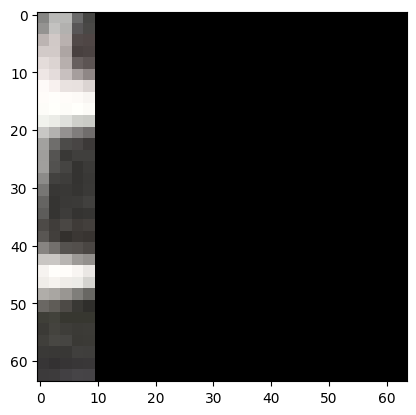

In [185]:
B2 = canvas[0:64, 64-10:64-10+64, :]
plt.imshow(B2)
B2_mask = canvas_mask[0:64, 64-10:64-10+64]
N=patches.shape[0]

# On duplique B2 et son masque N fois pour calculer le SSD contre tous les patches d'un coup

B2_dup = np.repeat(B2[np.newaxis, :, :, :], N, axis=0)
B2mask_dup = np.repeat(B2_mask[np.newaxis, :, :], N, axis=0)

# SSD masqué : on ne compare que sur les pixels déjà assignés (masque = 1)
# Les pixels non assignés (zone noire) sont ignorés grâce à la multiplication par le masque
diff = B2_dup - patches
sq = pow(diff, 2)

masked_sq = sq * B2mask_dup[:, :, :, np.newaxis]

ssds = masked_sq.sum(axis=(1,2,3))

#On a bien la bande de gauche qui est la bande de recouvrement et la zone noire est l'ensemble des pixels non assignés dans canvas


###2.4 Fast Prototyping: Looking for Candidate Patches
If you take the patch with the smallest ssd, it will be the one that is on the right of our first patch in `texture1`. This is not very interesting for texture generation, but we can use this to debug our code so far.

Look for the patch with the smallest ssd (Hint: use the `numy.argmin` function), and copy it at the expected place in `canvas`. Visualize the result in `canvas` - does it look correct?

best_idx = 54 best_ssd = 0


<Figure size 600x300 with 0 Axes>

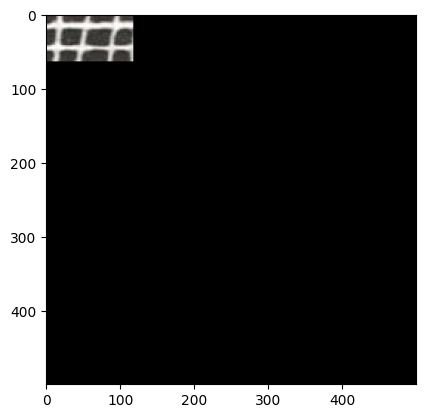

<Figure size 600x300 with 0 Axes>

In [186]:
# On prend le patch avec le plus petit SSD
best_idx = np.argmin(ssds)
print("best_idx =", best_idx, "best_ssd =", ssds[best_idx])

# On le colle dans canvas à la position de B2 et on met à jour le masque
canvas[0:64, 64-10:64-10+64, :] = patches[best_idx]
canvas_mask[0:64, 64-10:64-10+64] = 1
plt.imshow(canvas)
plt.figure(figsize=(6,3))

#Oui. Le patch sélectionné correspond à celui situé directement à droite du premier patch dans texture1, ce qui produit une continuation fluide et cohérente de la texture.
#Cela confirme que le calcul du SSD ainsi que l’utilisation du masque sont correctement implémentés.

Instead of taking the patch with the lowest ssd, the idea of the paper is to take a random one provided its ssd is still low.

The paper is not very explicit on how they do it. One simple method I found is to randomly sample a given percentage (say 5%) of the patches and keep the best one.

Write a function called `next_patch(ssds, patch_size, percentage)` that returns the index of such a patch.

In [187]:
def next_patch_index(ssds, percentage):
    N= len(ssds)
    #Nombre de patches candidats
    k=max(1, int(N*percentage/100))
    #Indices triés
    sorted_idx=np.argsort(ssds)
    #On garde les k meilleurs
    best_candidates=sorted_idx[:k]
    selected_idx= np.random.choice(best_candidates)
    return(selected_idx)




Now, we can simply choose a good patch for B2 by running:

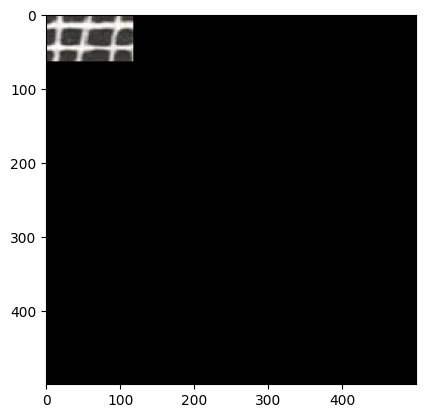

In [188]:
id = next_patch_index(ssds, 0.05)
B2 = patches[id]
canvas[0:64, 64-10:64-10+64, :] = B2
plt.imshow(canvas)

###2.5 Writing the `texture_synthesis` function (finally)

Use the code you wrote above to write a complete function `texture_synthesis(texture, W, H, patch_size, overlap, percentage)` that takes as input a `texture` image, the resolution `W`x`H` of the image to generate, the `patch_size`, the `overlap` between patches, and the `percentage` of patches to sample.

In [189]:
def paste_patch(canvas, canvas_mask, r, c, patch, patch_size):
    """
    Colle un patch dans le canvas à la position (r, c).
    Sur les pixels déjà remplis, on fait la moyenne entre 
    l'ancien et le nouveau pour lisser la transition.
    """
    existing = canvas[r:r+patch_size, c:c+patch_size, :].astype(np.float32)
    new_patch = patch.astype(np.float32)
    mask = canvas_mask[r:r+patch_size, c:c+patch_size, np.newaxis].astype(np.float32)

    # si mask=1 le pixel est déjà rempli et on fait la moyenne, si mask=0 le pixel est vide et on fait une copie directe
    blended = mask * ((existing + new_patch) / 2) + (1 - mask) * new_patch

    canvas[r:r+patch_size, c:c+patch_size, :] = blended.astype(np.uint8)
    canvas_mask[r:r+patch_size, c:c+patch_size] = 1

def texture_synthesis(texture, W, H, patch_size, overlap, percentage):
    canvas = np.zeros((H, W, 3), dtype=np.uint8)
    canvas_mask = np.zeros((H, W), dtype=np.uint8)
    Ht, Wt, Ct = texture.shape
    #Conditions
    assert Ct==3
    assert patch_size<=Ht and patch_size<=Wt
    stride = patch_size - overlap
    assert stride > 0
    # Extraction de tous les patches possibles de la texture source    
    num_patches_w = Wt - patch_size + 1
    num_patches_h = Ht - patch_size + 1
    N = num_patches_w * num_patches_h

    patches = np.zeros((N, patch_size, patch_size, 3), dtype=np.uint8)
    idx = 0
    for i in range(num_patches_h):
        for j in range(num_patches_w):
            patches[idx] = texture[i:i+patch_size, j:j+patch_size, :]
            idx += 1
    
    patches_f = patches.astype(np.float32)
    # Initialisation : un patch aléatoire en haut à gauche
    init_idx = np.random.randint(0, N)
    canvas[0:patch_size, 0:patch_size, :] = patches[init_idx]
    canvas_mask[0:patch_size, 0:patch_size] = 1
    
    # Remplissage ligne par ligne, colonne par colonne
    for r in range(0, H - patch_size + 1, stride):
        for c in range(0, W - patch_size + 1, stride):
            if r == 0 and c == 0:
                continue

            # Extraire B et son masque
            B = canvas[r:r+patch_size, c:c+patch_size, :].astype(np.float32)
            M = canvas_mask[r:r+patch_size, c:c+patch_size].astype(np.float32)

            diff = patches_f - B[None, :, :, :]
            sq = diff ** 2
            masked_sq = sq * M[None, :, :, None]
            ssds = masked_sq.sum(axis=(1, 2, 3))

            # Choix aléatoire parmi les meilleurs patches (cf. section 2.4)
            best_idx = next_patch_index(ssds, percentage)

            paste_patch(canvas, canvas_mask, r, c, patches[best_idx], patch_size) #2.6

    return canvas

You can test your function by running:

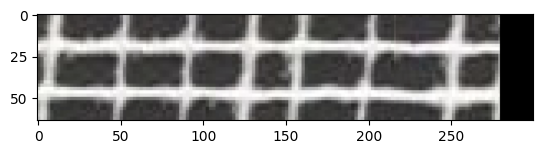

In [190]:
result = texture_synthesis(texture1, 300, 64, 64, 10, 0.05)
plt.imshow(result)

###2.6 Smoothing Things Out
Instead of simply 'pasting' the patches into the canvas, we can average the canvas and the patches where they overlap (the paper uses something more sophisticated but it is too ambitious for this assignment). Modify your `texture_synthesis` function accordingly. It is convenient to introduce a function that "pastes" the patch. (Hint: be careful when you add 2 uint8!)

Let's try our new function:

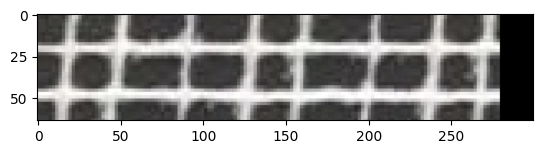

In [191]:
result = texture_synthesis(texture1, 300, 64, 64, 10, 0.05)
plt.imshow(result)

And with 2 rows:

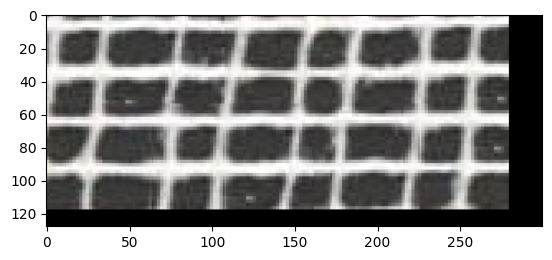

In [192]:
result = texture_synthesis(texture1, 300, 128, 64, 10, 0.05)
plt.imshow(result)

##2.7 Testing on Other Textures

You can dowload these other textures and try your function on them.  One thing the paper does not tell you is that you have to select the patch size relativement carefully to get good results...

In [193]:
!wget https://vincentlepetit.github.io/files/lectures/triva/bricks.png -O bricks.png
!wget https://vincentlepetit.github.io/files/lectures/triva/crackers.png -O crackers.png
!wget https://vincentlepetit.github.io/files/lectures/triva/chocolate.png -O chocolate.png

--2026-03-17 23:43:48--  https://vincentlepetit.github.io/files/lectures/triva/bricks.png
Resolving vincentlepetit.github.io (vincentlepetit.github.io)... 185.199.109.153, 185.199.110.153, 185.199.111.153, ...
Connecting to vincentlepetit.github.io (vincentlepetit.github.io)|185.199.109.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48093 (47K) [image/png]
Saving to: ‘bricks.png’

bricks.png          100%[===================>]  46.97K  --.-KB/s    in 0.01s   

2026-03-17 23:43:49 (3.23 MB/s) - ‘bricks.png’ saved [48093/48093]

--2026-03-17 23:43:49--  https://vincentlepetit.github.io/files/lectures/triva/crackers.png
Resolving vincentlepetit.github.io (vincentlepetit.github.io)... 185.199.109.153, 185.199.110.153, 185.199.111.153, ...
Connecting to vincentlepetit.github.io (vincentlepetit.github.io)|185.199.109.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 41880 (41K) [image/png]
Saving to: ‘crackers.png’

crackers.png     

In [194]:
bricks = np.array(imageio.imread('bricks.png'))
crackers = np.array(imageio.imread('crackers.png'))
chocolate = np.array(imageio.imread('chocolate.png'))

/var/folders/ch/n84hhlsn521bgb9s7cbmp3jw0000gn/T/ipykernel_3760/3875621803.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  bricks = np.array(imageio.imread('bricks.png'))
/var/folders/ch/n84hhlsn521bgb9s7cbmp3jw0000gn/T/ipykernel_3760/3875621803.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  crackers = np.array(imageio.imread('crackers.png'))
/var/folders/ch/n84hhlsn521bgb9s7cbmp3jw0000gn/T/ipykernel_3760/3875621803.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make thi

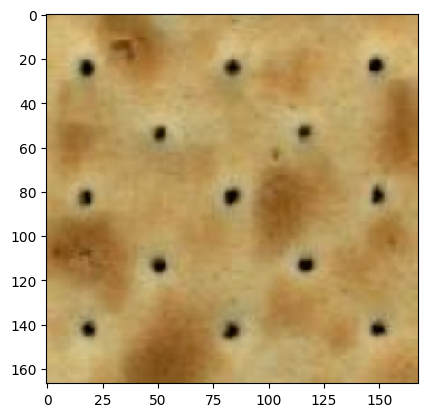

In [195]:
plt.imshow(crackers)

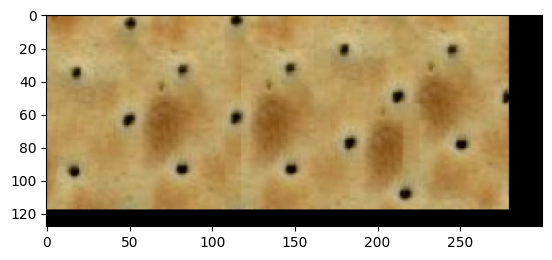

In [196]:
result = texture_synthesis(crackers, 300, 128, 64, 10, 0.05)
plt.imshow(result)


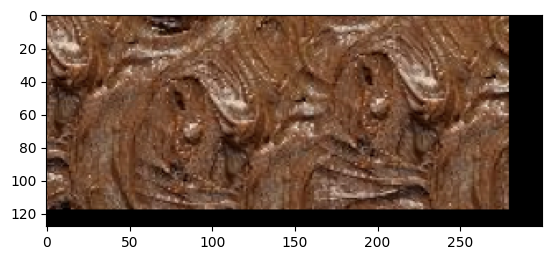

In [197]:
result2 = texture_synthesis(chocolate, 300, 128, 64, 10, 0.05)
plt.imshow(result2)

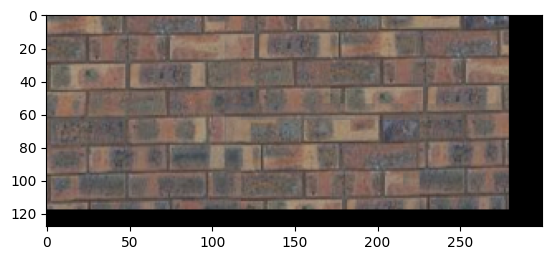

In [198]:
result3 = texture_synthesis(bricks, 300, 128, 64, 10, 0.05)
plt.imshow(result3)

##3. Object removal

The tower in the `montparnasse.png` image is in the region (310, 10)x(420, 290). Can you modify your `texture_synthesis` function to remove it from the image?

In [199]:
!wget https://VincentLepetit.github.io/files/lectures/triva/montparnasse.png

--2026-03-17 23:43:54--  https://vincentlepetit.github.io/files/lectures/triva/montparnasse.png
Resolving vincentlepetit.github.io (vincentlepetit.github.io)... 185.199.109.153, 185.199.110.153, 185.199.111.153, ...
Connecting to vincentlepetit.github.io (vincentlepetit.github.io)|185.199.109.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 270653 (264K) [image/png]
Saving to: ‘montparnasse.png.15’

montparnasse.png.15 100%[===================>] 264.31K  --.-KB/s    in 0.04s   

2026-03-17 23:43:54 (5.97 MB/s) - ‘montparnasse.png.15’ saved [270653/270653]



/var/folders/ch/n84hhlsn521bgb9s7cbmp3jw0000gn/T/ipykernel_3760/3866814649.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  montparnasse = np.array(imageio.imread('montparnasse.png'))


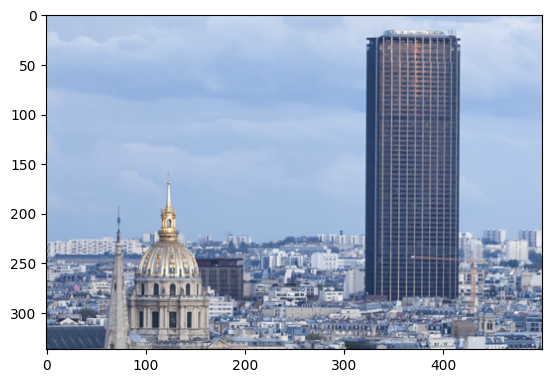

In [200]:
montparnasse = np.array(imageio.imread('montparnasse.png'))
plt.imshow(montparnasse)

In [201]:
# Ma démarche pour retirer la Tour Montparnasse (les blocs de fonction ne sont pas dans l'ordre)
#L'idée générale est de traiter la zone occupée par la tour comme un "trou" à remplir par inpainting patch-based : on cherche dans le reste de l'image des patches similaires au contexte connu autour du trou, et on les colle dedans.

### Étape 1 — Approche naïve : copie ligne par ligne (`remove_tower_linewise`)

#Ma première idée était la plus simple : pour chaque ligne `y` dans la zone de la tour (`y ∈ [10, 290]`), je copie directement les pixels situés juste à gauche de la tour pour boucher le trou.  
#Résultat: ça marche un peu sur les zones homogènes (ciel uniforme) mais ça crée des motifs évidents là où il y a des bâtiments ou des nuages, car la structure du côté gauche ne correspond pas à ce qu'il y aurait naturellement à droite. De plus ca ne répond pas à la consigne

### Étape 2 — Inpainting patch-based simple (`patch_inpaint`)

#J'ai adapté la fonction de synthèse de texture en mode inpainting :
#Je définis un masque `hole_mask` pour la zone de la tour `(x0=310, y0=10, x1=420, y1=290)`.
#Je construis une banque de patches **exclusivement** en dehors du masque (pas de patch contenant la tour).
#Je parcours une grille de positions couvrant le trou et, pour chaque fenêtre, je calcule le SSD uniquement sur les pixels déjà connus (`known_mask`), puis je copie le meilleur patch.
#J'ai ajouté un `blend_alpha` pour mélanger doucement les pixels à la frontière (overlap).

#Problème: l'image contient deux zones très différentes — le ciel en haut et les bâtiments en bas. En utilisant une seule banque de patches pour tout le trou, des patches de ciel tombaient dans la zone ville et inversement. Le résultat est incohérent.

### Étape 3 — Séparation ciel/ville (`texture_synthesis_sky_city`)

#Pour corriger ça, j'ai essayé de construire deux banques séparées: une pour le ciel (`y < 180`) et une pour la ville (`y > 220`), avec une ligne de partage `y_split`. Selon la ligne `r` traitée, j'utilise la banque correspondante.  
#Problème : la transition à la frontière ciel/ville restait artificielle, les patches des deux banques n'avaient pas de contexte commun, ce qui créait une "bande" visible à l'horizon.

### Étape 4 — Inpainting avec priorité et passes multiples (`inpaint_zone` / `
# `)

#J'ai introduit un remplissage intelligent par priorité :
#On trie les positions du trou par nombre de pixels déjà connus dans leur fenêtre (les fenêtres avec le plus de contexte connu sont traitées en premier).
#On recommence jusqu'à ce que le trou soit entièrement rempli (boucle `while changed`).
#On ajoute un `forbidden_margin` pour exclure les patches trop proches de la tour (afin d'éviter d'utiliser des pixels encore contaminés).
#Plusieurs passes (`n_passes`) : la première passe remplit les pixels inconnus, la deuxième affine par blending.

#Problème persistant: même avec la séparation ciel/ville, la zone de l'horizon reste difficile — les patches ne s'enchaînent pas naturellement à la jonction.

### Étape 5 — Restriction par colonne (`build_source_patches_rect`)

#Pour mieux cibler les zones de source, j'ai ajouté des paramètres `col_min`/`col_max` pour ne prendre que des patches d'une sous-région rectangulaire précise. L'idée était de ne pas utiliser des patches venant de colonnes trop éloignées dans l'image (risque de texture incohérente).

### Étape 6 — Approche finale : deux banques et feathering (`remove_object_split`)

#La version la plus aboutie combine tout :
#Deux banques complètement indépendantes (ciel pur / ville pure), avec `split_source` comme frontière.
#Un `blend_weight` différent pour le ciel (plus faible, pour éviter des contrastes trop brutaux dans les zones nuageuses) et pour la ville.
#Un paramètre `feather` pour adoucir la transition à la frontière ciel/ville.
#La fonction `add_patch_tour` gère le mélange : sur les pixels déjà connus, elle fait une interpolation `(1 - blend_weight) * ancien + blend_weight * nouveau` ; sur les pixels inconnus (trou), elle copie directement le patch.

#Bilan : les résultats sont nettement meilleurs mais restent imparfaits à la jonction ciel/bâtiments, qui est la zone la plus difficile car elle mélange deux textures très différentes.

#J'espère avoir expliqué tout mon raisonnement, la dernière image est la meilleure que j'ai pu obtenir. J'ai tenu à laisser mes premières fonctions car elles font parti de mon processus de réflexion mais s'il faut évaliuer une fonction plutôt privilégier la dernière

In [202]:
#Etape 1
def remove_tower_linewise(image):
    img = image.copy().astype(np.float32)

    x0, y0, x1, y1 = 310, 10, 420, 290

    for y in range(y0, y1):
        # largeur du trou
        width = x1 - x0

        # zone source juste à gauche de la tour
        source_start = x0 - width
        source_end = x0

        if source_start < 0:
            continue

        img[y, x0:x1, :] = img[y, source_start:source_end, :]

    return np.clip(img, 0, 255).astype(np.uint8)

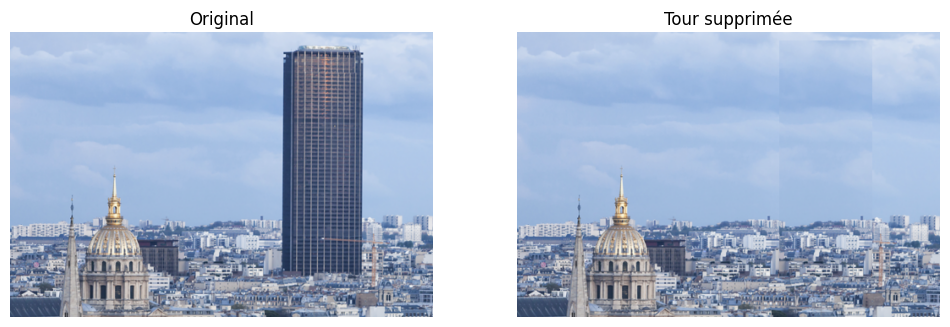

In [203]:
result = remove_tower_linewise(montparnasse)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(montparnasse)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Tour supprimée")
plt.axis("off")

plt.show()

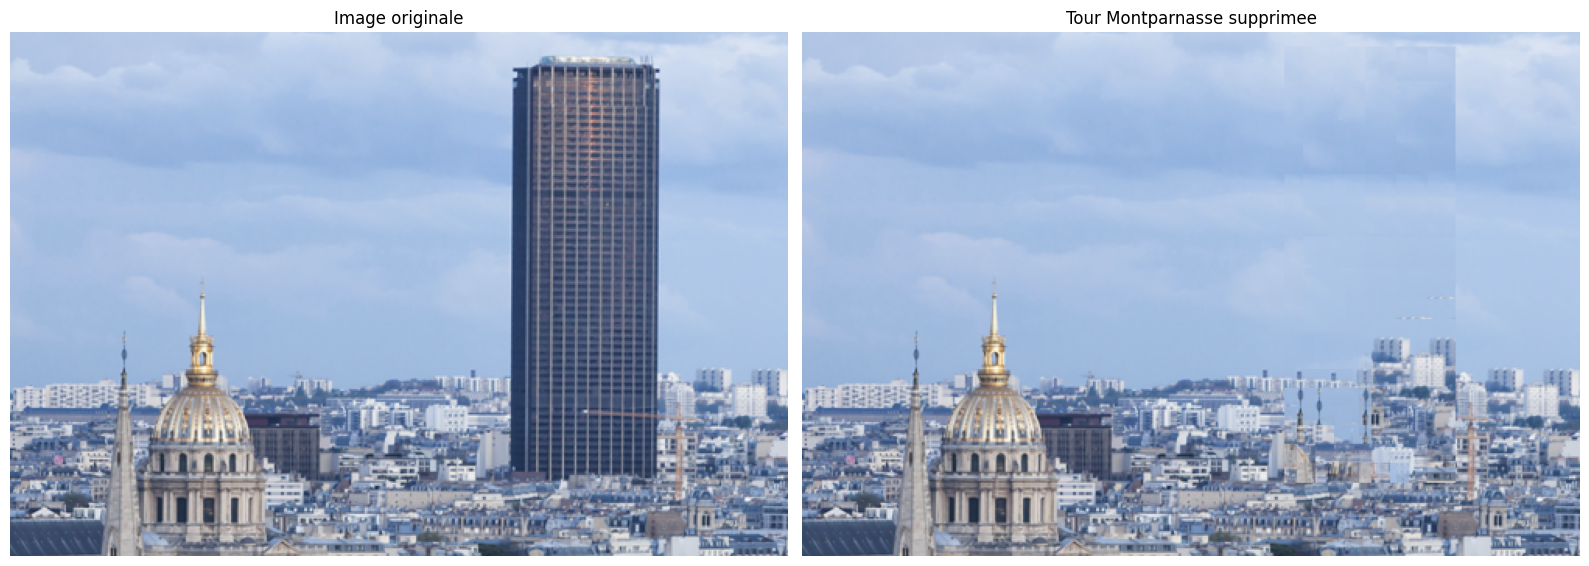

In [204]:
#Etape 2 : Inpainting patch-based simple
from __future__ import annotations
import imageio.v2 as imageio

DEFAULT_TOWER_RECT = (310, 10, 420, 290)  # (x0, y0, x1, y1) de la tour


def next_patch_index(ssds, percentage, rng):
    # Parmi tous les patches, garde les `percentage`% meilleurs et en tire un au hasard
    candidate_count = max(1, int(np.ceil(ssds.size * percentage)))
    best_ids = np.argpartition(ssds, candidate_count - 1)[:candidate_count]
    return int(rng.choice(best_ids))


def build_source_patches(image, forbidden_mask, patch_size, step, source_ymin=0, source_ymax=None):
    # Extrait tous les patches de l'image en sautant ceux qui touchent la zone interdite (la tour)
    h, w, _ = image.shape
    if source_ymax is None:
        source_ymax = h
    patches = []
    for row in range(source_ymin, min(source_ymax, h - patch_size + 1), step):
        for col in range(0, w - patch_size + 1, step):
            if forbidden_mask[row:row+patch_size, col:col+patch_size].any():
                continue  # patch contient la tour est ignoré
            patches.append(image[row:row+patch_size, col:col+patch_size])
    if not patches:
        raise ValueError("No valid source patches were found outside the forbidden area.")
    return np.stack(patches).astype(np.float32)


def cover_positions(start, end, limit, patch_size, overlap):
    # Calcule les positions de patches nécessaires pour couvrir entièrement [start, end], en commençant un peu avant start pour avoir de l'overlap avec le contexte connu
    stride = patch_size - overlap
    positions = []
    pos = max(0, start - stride)
    while True:
        positions.append(pos)
        if pos + patch_size >= end:
            break
        max_next = min(limit - patch_size, end - patch_size)
        next_pos = min(pos + stride, max_next)
        if next_pos <= pos:
            if positions[-1] != max_next:
                positions.append(max_next)
            break
        pos = next_pos
    return positions


def patch_inpaint(image, rect, patch_size=32, overlap=12, percentage=0.01,
                  source_step=4, seed=0, source_ymin=0, source_ymax=None):
    x0, y0, x1, y1 = rect
    h, w, _ = image.shape

    # Masque du trou à remplir
    hole_mask = np.zeros((h, w), dtype=bool)
    hole_mask[y0:y1, x0:x1] = True

    known_mask = ~hole_mask  # pixels déjà connus (hors tour)
    canvas = image.astype(np.float32).copy()
    source_patches = build_source_patches(image, hole_mask, patch_size, source_step, source_ymin, source_ymax)
    rng = np.random.default_rng(seed)

    row_positions = cover_positions(y0, y1, h, patch_size, overlap)
    col_positions = cover_positions(x0, x1, w, patch_size, overlap)

    # Boucle jusqu'à ce que tous les pixels du trou soient remplis
    while np.any(hole_mask & ~known_mask):
        missing_before = int(np.count_nonzero(hole_mask & ~known_mask))

        for row in row_positions:
            for col in col_positions:
                local_hole = hole_mask[row:row+patch_size, col:col+patch_size]
                if not local_hole.any():
                    continue  # cette fenêtre ne contient pas de trou

                window = canvas[row:row+patch_size, col:col+patch_size]
                window_known = known_mask[row:row+patch_size, col:col+patch_size]
                if not window_known.any():
                    continue  # si aucun pixel connu alors pas de contexte pour le SSD

                # SSD pondéré par le masque : on compare seulement sur les pixels connus
                weights = window_known.astype(np.float32)
                diff = source_patches - window[None, :, :, :]
                ssds = (diff * diff * weights[None, :, :, None]).sum(axis=(1, 2, 3))
                patch = source_patches[next_patch_index(ssds, percentage, rng)]

                # Si Pixels inconnus alors copie directe du patch
                new_pixels = local_hole & ~window_known
                if new_pixels.any():
                    window[new_pixels] = patch[new_pixels]

                # Si Pixels connus dans le trou (overlap) alors mélange léger pour adoucir la jointure
                overlap_pixels = local_hole & window_known
                if overlap_pixels.any():
                    alpha = 0.15
                    window[overlap_pixels] = (1-alpha)*window[overlap_pixels] + alpha*patch[overlap_pixels]

                window_known[local_hole] = True  # marque ces pixels comme remplis

        missing_after = int(np.count_nonzero(hole_mask & ~known_mask))
        if missing_after == 0:
            break
        if missing_after >= missing_before:
            raise RuntimeError("The inpainting loop stalled before filling the full rectangle.")

    return np.clip(canvas, 0, 255).astype(np.uint8)


#Application en deux passes pour gérer ciel et ville séparément

original = np.array(imageio.imread("montparnasse.png"))

# Passe 1 : remplir la partie ciel (patch grand car texture homogène)
img1 = patch_inpaint(original, (310, 10, 420, 185),
                     patch_size=32, overlap=12, percentage=1e-6, source_step=3, seed=0)

# Passe 2 : remplir la partie ville sur img1 (patch plus petit car texture fine)
img2 = patch_inpaint(img1, (310, 185, 420, 290),
                     patch_size=20, overlap=8, percentage=1e-6, source_step=1, seed=1)

plot_comparison(original, img2)
plt.show()


In [205]:
#Etape 3 - Séparation ciel/ville (deux banques)
# enlever le canal alpha
if montparnasse.shape[2] == 4:
    montparnasse = montparnasse[:, :, :3]

def build_patches_from_region(texture, patch_size, region):
    """
    region = (x0, y0, x1, y1) dans la texture source.
    Retourne patches de taille (N, patch_size, patch_size, 3)
    """
    x0, y0, x1, y1 = region
    crop = texture[y0:y1, x0:x1, :]
    Ht, Wt, Ct = crop.shape
    assert Ct == 3
    assert patch_size <= Ht and patch_size <= Wt

    num_patches_w = Wt - patch_size + 1
    num_patches_h = Ht - patch_size + 1
    N = num_patches_w * num_patches_h

    patches = np.zeros((N, patch_size, patch_size, 3), dtype=np.uint8)
    idx = 0
    for i in range(num_patches_h):
        for j in range(num_patches_w):
            patches[idx] = crop[i:i+patch_size, j:j+patch_size, :]
            idx += 1

    return patches, patches.astype(np.float32)

def texture_synthesis_sky_city(texture, W, H, patch_size, overlap, percentage,
                              sky_region, city_region, y_split):
    """
    sky_region / city_region : (x0,y0,x1,y1) dans la texture source
    y_split : ligne (en pixels) dans l'image générée
    """
    rng = np.random.default_rng(0)
    canvas = np.zeros((H, W, 3), dtype=np.uint8)
    canvas_mask = np.zeros((H, W), dtype=np.uint8)

    stride = patch_size - overlap
    assert stride > 0

    # 2 banques de patches
    sky_patches, sky_patches_f = build_patches_from_region(texture, patch_size, sky_region)
    city_patches, city_patches_f = build_patches_from_region(texture, patch_size, city_region)

    # init : on démarre dans le ciel (ou adapte si H petit)
    init_bank = sky_patches if 0 < y_split else city_patches
    init_idx = np.random.randint(0, init_bank.shape[0])
    canvas[0:patch_size, 0:patch_size, :] = init_bank[init_idx]
    canvas_mask[0:patch_size, 0:patch_size] = 1

    for r in range(0, H - patch_size + 1, stride):
        # choisir banque selon la hauteur
        if r < y_split:
            patches = sky_patches
            patches_f = sky_patches_f
        else:
            patches = city_patches
            patches_f = city_patches_f

        for c in range(0, W - patch_size + 1, stride):
            if r == 0 and c == 0:
                continue

            B = canvas[r:r+patch_size, c:c+patch_size, :].astype(np.float32)
            M = canvas_mask[r:r+patch_size, c:c+patch_size].astype(np.float32)

            diff = patches_f - B[None, :, :, :]
            ssds = ((diff ** 2) * M[None, :, :, None]).sum(axis=(1, 2, 3))

            best_idx = next_patch_index(ssds, percentage, rng)

            canvas[r:r+patch_size, c:c+patch_size, :] = patches[best_idx]
            canvas_mask[r:r+patch_size, c:c+patch_size] = 1

    return canvas

Himg, Wimg, _ = montparnasse.shape

sky_region  = (0, 0, Wimg, 180)          
city_region = (0, 220, Wimg, Himg)       

result = texture_synthesis_sky_city(
    montparnasse,
    W=500, H=500,
    patch_size=32, overlap=12,
    percentage=0.05,            
    sky_region=sky_region,
    city_region=city_region,
    y_split=200             
)

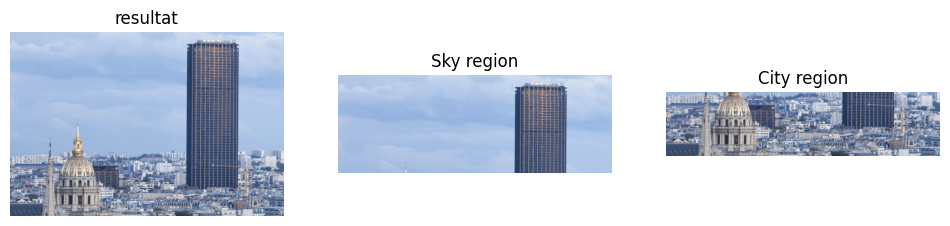

In [206]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(montparnasse)
plt.title("resultat")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(montparnasse[0:180, 0:Wimg])
plt.title("Sky region")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(montparnasse[220:Himg, 0:Wimg]) 
plt.title("City region")
plt.axis("off")

plt.show()

In [207]:
#Etape 4: inpainting avec priorité et passes multiples
def next_patch_index(ssds, percentage, rng):
    k = max(1, int(np.ceil(ssds.size * percentage)))
    best_ids = np.argpartition(ssds, k - 1)[:k]
    return int(rng.choice(best_ids))

def build_source_patches(image, forbidden, patch_size, step, row_min=0, row_max=None):
    h, w = image.shape[:2]
    if row_max is None:
        row_max = h
    patches = []
    for r in range(row_min, min(row_max, h - patch_size + 1), step):
        for c in range(0, w - patch_size + 1, step):
            if forbidden[r:r+patch_size, c:c+patch_size].any():
                continue
            patches.append(image[r:r+patch_size, c:c+patch_size])
    if not patches:
        raise ValueError(f"No patches rows [{row_min},{row_max})")
    return np.stack(patches).astype(np.float32)

def inpaint_zone(canvas, filled, hole_mask, source_patches,
                 positions, patch_size, percentage, rng,
                 n_passes=2, blend_alpha=0.15):
    for pass_num in range(n_passes):
        changed = True
        while changed:
            changed = False
            scored = []
            for r, c in positions:
                local_hole = hole_mask[r:r+patch_size, c:c+patch_size]
                local_filled = filled[r:r+patch_size, c:c+patch_size]
                n_unfilled = int((local_hole & ~local_filled).sum())
                n_known = int(local_filled.sum())
                if n_unfilled == 0 and pass_num == 0:
                    continue
                if n_known == 0:
                    continue
                scored.append((r, c, n_known, n_unfilled))
            if not scored:
                break
            scored.sort(key=lambda x: -x[2])
            for r, c, _, _ in scored:
                local_hole = hole_mask[r:r+patch_size, c:c+patch_size]
                local_filled = filled[r:r+patch_size, c:c+patch_size]
                unfilled = local_hole & ~local_filled
                if pass_num == 0 and not unfilled.any():
                    continue
                window = canvas[r:r+patch_size, c:c+patch_size]
                weights = local_filled.astype(np.float32)
                diff = source_patches - window[None, :, :, :]
                ssds = (diff * diff * weights[None, :, :, None]).sum(axis=(1, 2, 3))
                idx = next_patch_index(ssds, percentage, rng)
                patch = source_patches[idx]
                if unfilled.any():
                    window[unfilled] = patch[unfilled]
                    local_filled[unfilled] = True
                    changed = True
                if pass_num > 0:
                    already = local_hole & ~unfilled
                    if already.any():
                        window[already] = (1-blend_alpha)*window[already] + blend_alpha*patch[already]

def remove_tower(image, tower_rect=(310, 10, 420, 290), sky_city_y=240,
                 patch_size=28, overlap=12, percentage=0.003,
                 source_step=3, seed=42, n_passes=2, blend_alpha=0.15):
    x0, y0, x1, y1 = tower_rect
    H, W, C = image.shape
    rng = np.random.default_rng(seed)
    canvas = image.astype(np.float32).copy()
    forbidden = np.zeros((H, W), dtype=bool)
    forbidden[y0:y1, x0:x1] = True
    stride = patch_size - overlap

    #CIEL
    sky_hole = np.zeros((H, W), dtype=bool)
    sky_hole[y0:sky_city_y, x0:x1] = True
    sky_filled = ~sky_hole.copy()
    sky_patches = build_source_patches(image, forbidden, patch_size, source_step, 0, sky_city_y)
    sky_pos = [(r, c) for r in range(max(0, y0-overlap), min(H-patch_size, sky_city_y)+1, stride)
                       for c in range(max(0, x0-overlap), min(W-patch_size, x1)+1, stride)]
    inpaint_zone(canvas, sky_filled, sky_hole, sky_patches, sky_pos, patch_size, percentage, rng, n_passes, blend_alpha)

    #VILLE
    city_hole = np.zeros((H, W), dtype=bool)
    city_hole[sky_city_y:y1, x0:x1] = True
    city_filled = ~city_hole.copy()
    city_patches = build_source_patches(image, forbidden, patch_size, source_step, max(0, sky_city_y-patch_size), H)
    city_pos = [(r, c) for r in range(max(0, sky_city_y-overlap), min(H-patch_size, y1)+1, stride)
                        for c in range(max(0, x0-overlap), min(W-patch_size, x1)+1, stride)]
    inpaint_zone(canvas, city_filled, city_hole, city_patches, city_pos, patch_size, percentage, rng, n_passes, blend_alpha)

    return np.clip(canvas, 0, 255).astype(np.uint8)

result = remove_tower(montparnasse)

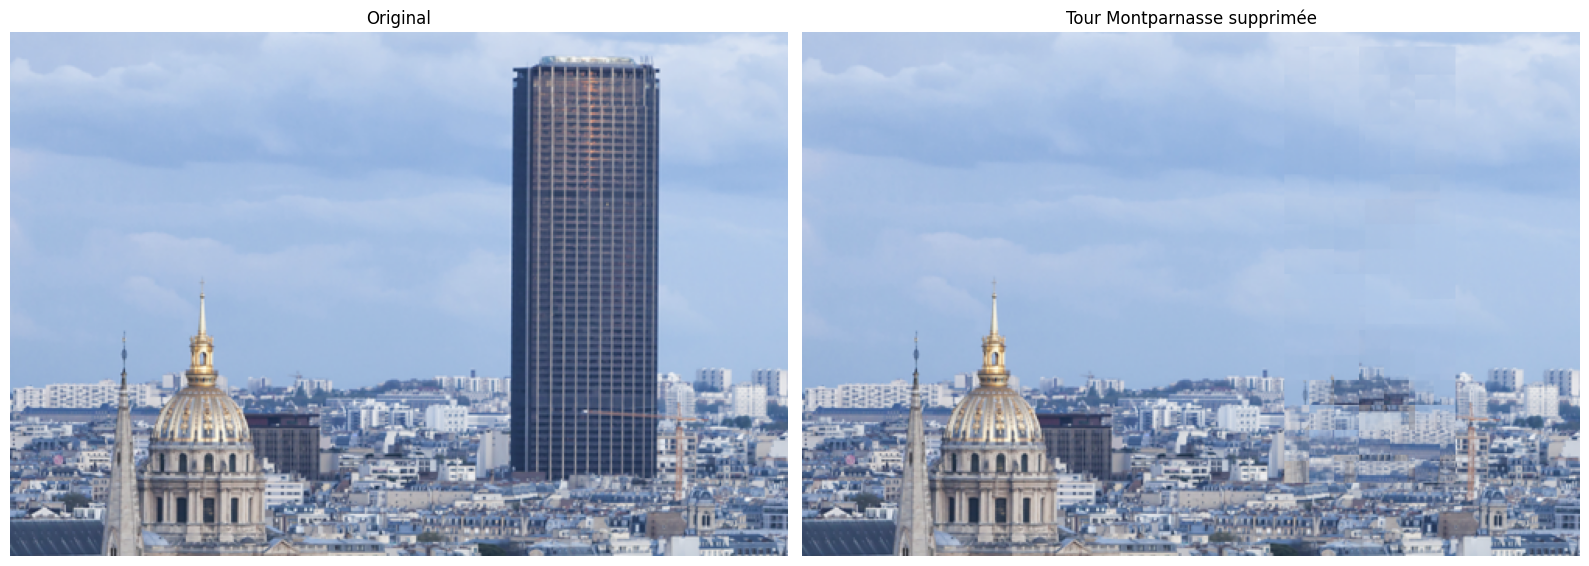

In [208]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(montparnasse)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(result)
axes[1].set_title("Tour Montparnasse supprimée")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [209]:
def next_patch_index(ssds, percentage, rng):
    k = max(1, int(np.ceil(ssds.size * percentage)))
    best_ids = np.argpartition(ssds, k - 1)[:k]
    return int(rng.choice(best_ids))

def build_source_patches(image, forbidden, patch_size, step, row_min=0, row_max=None):
    h, w = image.shape[:2]
    if row_max is None:
        row_max = h
    patches = []
    for r in range(row_min, min(row_max, h - patch_size + 1), step):
        for c in range(0, w - patch_size + 1, step):
            if forbidden[r:r+patch_size, c:c+patch_size].any():
                continue
            patches.append(image[r:r+patch_size, c:c+patch_size])
    if not patches:
        raise ValueError(f"No patches rows [{row_min},{row_max})")
    return np.stack(patches).astype(np.float32)

def inpaint_zone(canvas, filled, hole_mask, source_patches,
                 positions, patch_size, percentage, rng,
                 n_passes=2, blend_alpha=0.15):
    for pass_num in range(n_passes):
        changed = True
        while changed:
            changed = False
            scored = []
            for r, c in positions:
                local_hole = hole_mask[r:r+patch_size, c:c+patch_size]
                local_filled = filled[r:r+patch_size, c:c+patch_size]
                n_unfilled = int((local_hole & ~local_filled).sum())
                n_known = int(local_filled.sum())
                if n_unfilled == 0 and pass_num == 0:
                    continue
                if n_known == 0:
                    continue
                scored.append((r, c, n_known, n_unfilled))
            if not scored:
                break
            scored.sort(key=lambda x: -x[2])
            for r, c, _, _ in scored:
                local_hole = hole_mask[r:r+patch_size, c:c+patch_size]
                local_filled = filled[r:r+patch_size, c:c+patch_size]
                unfilled = local_hole & ~local_filled
                if pass_num == 0 and not unfilled.any():
                    continue
                window = canvas[r:r+patch_size, c:c+patch_size]
                weights = local_filled.astype(np.float32)
                diff = source_patches - window[None, :, :, :]
                ssds = (diff * diff * weights[None, :, :, None]).sum(axis=(1, 2, 3))
                idx = next_patch_index(ssds, percentage, rng)
                patch = source_patches[idx]
                if unfilled.any():
                    window[unfilled] = patch[unfilled]
                    local_filled[unfilled] = True
                    changed = True
                if pass_num > 0:
                    already = local_hole & ~unfilled
                    if already.any():
                        window[already] = (1-blend_alpha)*window[already] + blend_alpha*patch[already]

def remove_tower(image, tower_rect=(310, 10, 420, 290),
                 sky_top=170, horizon_bottom=230,
                 patch_size=24, overlap=10, percentage=0.003,
                 source_step=3, seed=42, n_passes=2, blend_alpha=0.15):
    """
    3 zones INDEPENDANTES, chacune avec sa propre banque de patches:
      - Ciel pur:  lignes 10 -> sky_top     (patches pris dans lignes 0 -> sky_top)
      - Horizon:   lignes sky_top -> horizon_bottom  (patches pris autour de cette bande)
      - Ville:     lignes horizon_bottom -> 290  (patches pris dans le bas de l'image)
    """
    x0, y0, x1, y1 = tower_rect
    H, W, C = image.shape
    rng = np.random.default_rng(seed)
    canvas = image.astype(np.float32).copy()
    forbidden = np.zeros((H, W), dtype=bool)
    forbidden[y0:y1, x0:x1] = True
    stride = patch_size - overlap

    # Définition des 3 zones: (nom, trou_haut, trou_bas, source_haut, source_bas)
    zones = [
        ("Ciel",    y0,              sky_top,         0,                              sky_top + patch_size),
        ("Horizon", sky_top,         horizon_bottom,  max(0, sky_top - patch_size),    horizon_bottom + patch_size),
        ("Ville",   horizon_bottom,  y1,              max(0, horizon_bottom - patch_size), H),
    ]

    for name, hole_top, hole_bot, src_top, src_bot in zones:
        if hole_top >= hole_bot:
            continue
        
        # Masque du trou pour cette zone uniquement
        zone_hole = np.zeros((H, W), dtype=bool)
        zone_hole[hole_top:hole_bot, x0:x1] = True
        zone_filled = ~zone_hole.copy()

        # Patches sources pris uniquement dans la bande correspondante
        src_patches = build_source_patches(image, forbidden, patch_size, source_step,
                                           row_min=src_top, row_max=min(src_bot, H))

        # Positions de placement
        r_start = max(0, hole_top - overlap)
        r_end = min(H - patch_size, hole_bot)
        c_start = max(0, x0 - overlap)
        c_end = min(W - patch_size, x1)
        positions = [(r, c) for r in range(r_start, r_end + 1, stride)
                             for c in range(c_start, c_end + 1, stride)]

        print(f"{name}: lignes [{hole_top},{hole_bot}), {src_patches.shape[0]} patches source")
        inpaint_zone(canvas, zone_filled, zone_hole, src_patches,
                     positions, patch_size, percentage, rng, n_passes, blend_alpha)

    return np.clip(canvas, 0, 255).astype(np.uint8)

In [210]:
result = remove_tower(montparnasse)

Ciel: lignes [10,170), 7475 patches source
Horizon: lignes [170,230), 4140 patches source
Ville: lignes [230,290), 4492 patches source


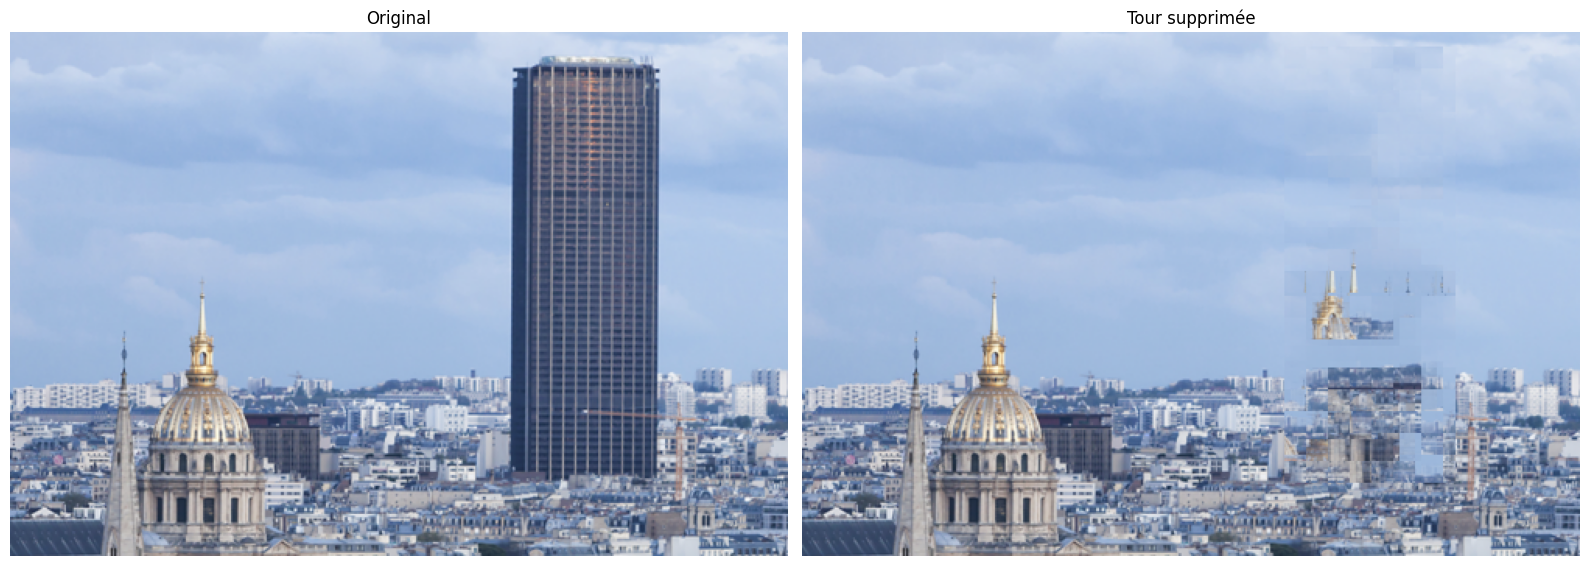

In [211]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(montparnasse); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(result); axes[1].set_title("Tour supprimée"); axes[1].axis("off")
plt.tight_layout()
plt.show()

In [212]:
#Etape 5: Restriction par colonne
def next_patch_index(ssds, percentage, rng):
    k = max(1, int(np.ceil(ssds.size * percentage)))
    best_ids = np.argpartition(ssds, k - 1)[:k]
    return int(rng.choice(best_ids))

def build_source_patches_rect(image, forbidden, patch_size, step,
                               row_min=0, row_max=None, col_min=0, col_max=None):
    h, w = image.shape[:2]
    if row_max is None: row_max = h
    if col_max is None: col_max = w
    patches = []
    for r in range(row_min, min(row_max, h - patch_size + 1), step):
        for c in range(col_min, min(col_max, w - patch_size + 1), step):
            if forbidden[r:r+patch_size, c:c+patch_size].any():
                continue
            patches.append(image[r:r+patch_size, c:c+patch_size])
    if not patches:
        raise ValueError(f"No patches")
    return np.stack(patches).astype(np.float32)

def inpaint_zone(canvas, filled, hole_mask, source_patches,
                 positions, patch_size, percentage, rng,
                 n_passes=2, blend_alpha=0.15):
    for pass_num in range(n_passes):
        changed = True
        while changed:
            changed = False
            scored = []
            for r, c in positions:
                local_hole = hole_mask[r:r+patch_size, c:c+patch_size]
                local_filled = filled[r:r+patch_size, c:c+patch_size]
                n_unfilled = int((local_hole & ~local_filled).sum())
                n_known = int(local_filled.sum())
                if n_unfilled == 0 and pass_num == 0: continue
                if n_known == 0: continue
                scored.append((r, c, n_known, n_unfilled))
            if not scored: break
            scored.sort(key=lambda x: -x[2])
            for r, c, _, _ in scored:
                local_hole = hole_mask[r:r+patch_size, c:c+patch_size]
                local_filled = filled[r:r+patch_size, c:c+patch_size]
                unfilled = local_hole & ~local_filled
                if pass_num == 0 and not unfilled.any(): continue
                window = canvas[r:r+patch_size, c:c+patch_size]
                weights = local_filled.astype(np.float32)
                diff = source_patches - window[None, :, :, :]
                ssds = (diff * diff * weights[None, :, :, None]).sum(axis=(1, 2, 3))
                idx = next_patch_index(ssds, percentage, rng)
                patch = source_patches[idx]
                if unfilled.any():
                    window[unfilled] = patch[unfilled]
                    local_filled[unfilled] = True
                    changed = True
                if pass_num > 0:
                    already = local_hole & ~unfilled
                    if already.any():
                        window[already] = (1-blend_alpha)*window[already] + blend_alpha*patch[already]

def remove_tower(image, tower_rect=(310, 10, 420, 290),
                 patch_size=24, overlap=10, percentage=0.002,
                 source_step=3, seed=42, n_passes=3, blend_alpha=0.2):
    x0, y0, x1, y1 = tower_rect
    H, W, C = image.shape
    rng = np.random.default_rng(seed)
    canvas = image.astype(np.float32).copy()
    
    # Zone interdite: tour + marge + grue à droite
    forbidden = np.zeros((H, W), dtype=bool)
    forbidden[max(0,y0-60):min(H,y1+20), max(0,x0-60):min(W,x1+60)] = True
    forbidden[230:290, 420:460] = True  # grue/cheminée à droite
    
    stride = patch_size - overlap

    # 4 zones avec sources précises
    zones = [
        ("Ciel",         y0,   160,   0,    170,   0,    W),
        ("Horizon haut", 160,  200,   140,  220,   0,    250),
        ("Horizon bas",  200,  240,   180,  260,   0,    W),
        ("Ville",        240,  y1,    220,  H,     0,    W),
    ]

    for name, hole_top, hole_bot, src_r0, src_r1, src_c0, src_c1 in zones:
        if hole_top >= hole_bot: continue
        zone_hole = np.zeros((H, W), dtype=bool)
        zone_hole[hole_top:hole_bot, x0:x1] = True
        zone_filled = ~zone_hole.copy()
        src_patches = build_source_patches_rect(
            image, forbidden, patch_size, source_step,
            row_min=src_r0, row_max=min(src_r1, H),
            col_min=src_c0, col_max=min(src_c1, W))
        r_start = max(0, hole_top - overlap)
        r_end = min(H - patch_size, hole_bot)
        c_start = max(0, x0 - overlap)
        c_end = min(W - patch_size, x1)
        positions = [(r, c) for r in range(r_start, r_end + 1, stride)
                             for c in range(c_start, c_end + 1, stride)]
        print(f"{name}: [{hole_top},{hole_bot}), {src_patches.shape[0]} patches")
        inpaint_zone(canvas, zone_filled, zone_hole, src_patches,
                     positions, patch_size, percentage, rng, n_passes, blend_alpha)

    return np.clip(canvas, 0, 255).astype(np.uint8)

result = remove_tower(montparnasse, n_passes=2, blend_alpha=0.1)

Ciel: [10,160), 4332 patches
Horizon haut: [160,200), 2052 patches
Horizon bas: [200,240), 2052 patches
Ville: [240,290), 2598 patches


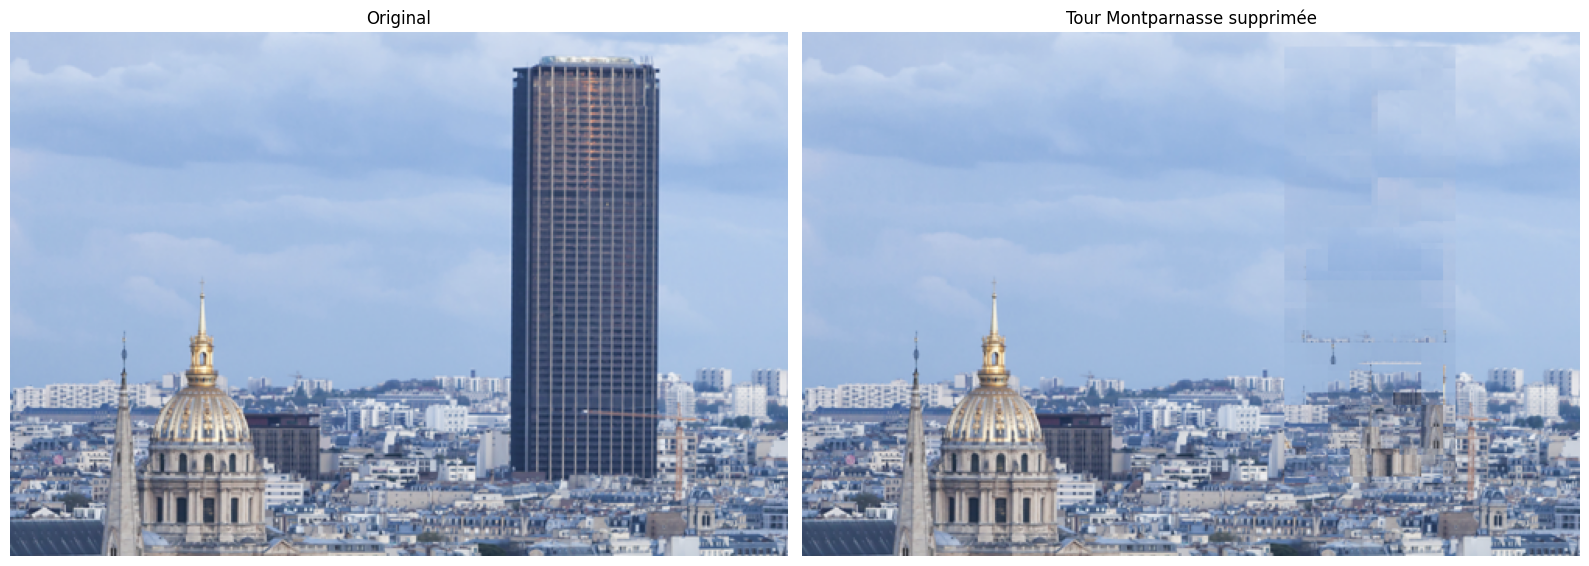

In [213]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(montparnasse); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(result); axes[1].set_title("Tour Montparnasse supprimée"); axes[1].axis("off")
plt.tight_layout()
plt.show()

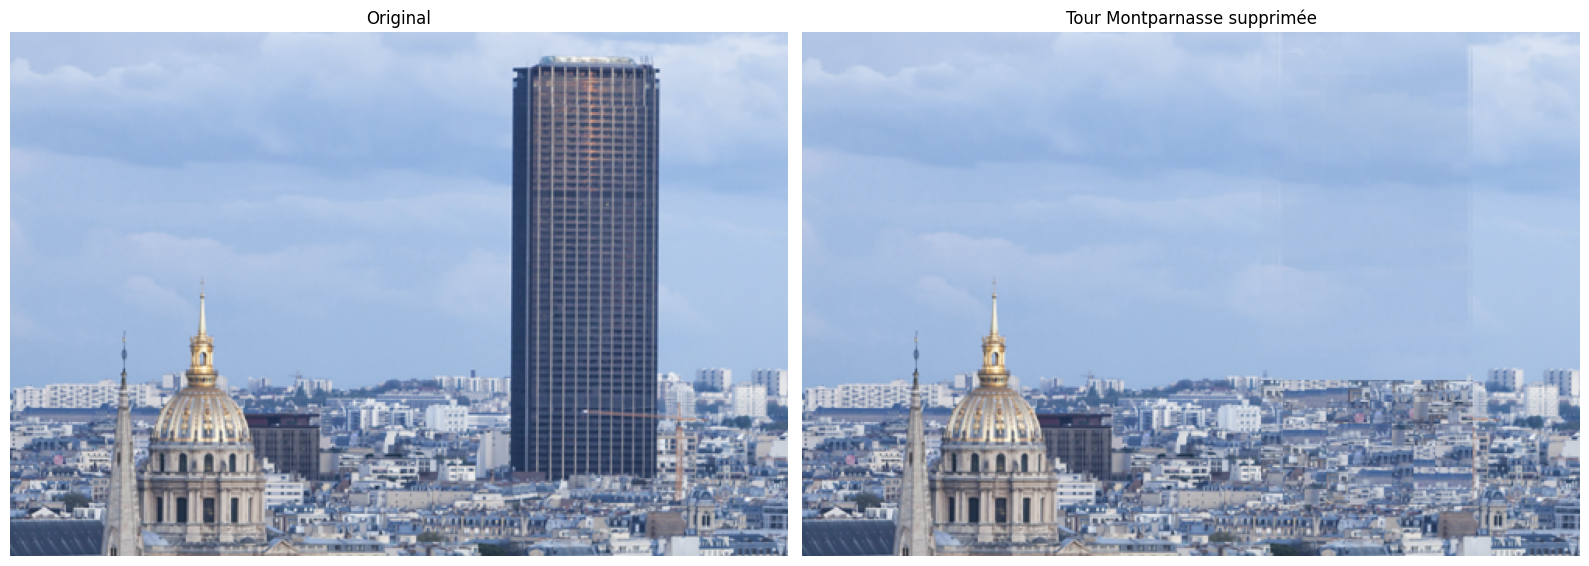

In [215]:
#Etape 6: Deux banques + feathering (version finale)
def add_patch_tour(row, col, canvas, canvas_mask, patch_size, source_patches, percentage, blend_weight=0.8):
    """
    Place le meilleur patch (au sens du SSD) à la position (row, col) du canvas.
    On échantillonne aléatoirement un sous-ensemble de patches pour éviter 
    de saturer la mémoire sur de gros tableaux.
    blend_weight : 1.0 = net (on écrase), 0.5 = moyenne (plus flou)
    """
    B2 = canvas[row:row+patch_size, col:col+patch_size, :]
    B2_mask = canvas_mask[row:row+patch_size, col:col+patch_size]

    # Sous-échantillonnage aléatoire pour limiter le coût mémoire

    n_total = len(source_patches)
    n_samples = max(1, int(percentage * n_total))
    sampled_idx = np.random.choice(n_total, n_samples, replace=False)
    sampled_patches = source_patches[sampled_idx]

    # SSD uniquement sur les pixels déjà connus (masque = 1)

    B2_mask_3c = B2_mask[:, :, np.newaxis]
    diff = sampled_patches - B2
    ssds = (diff ** 2 * B2_mask_3c).sum(axis=(1, 2, 3))

    best_local = np.argmin(ssds)
    best_patch = source_patches[sampled_idx[best_local]]

    # Sur l'overlap (connu) : mélange ancien/nouveau selon blend_weight
    # Sur le trou (inconnu) : copie directe du patch
    B2_float = B2.astype(np.float32)
    result = B2_mask_3c * ((1 - blend_weight) * B2_float + blend_weight * best_patch) + (1 - B2_mask_3c) * best_patch

    canvas[row:row+patch_size, col:col+patch_size, :] = result.astype(np.uint8)
    canvas_mask[row:row+patch_size, col:col+patch_size] = 1

def remove_object_split(texture, ymin, ymax, xmin, xmax, patch_size, overlap, percentage, max_patches, split_source=245, split_fill=225, blend_weight=0.85, blend_weight_sky=0.5, feather=8):
    """
    Supprime la tour Montparnasse par inpainting patch-based avec deux banques séparées.
    
    On sépare ciel et ville car un inpainting global mélangeait les deux :
    des patches de ciel apparaissaient dans la zone ville et inversement.
    
    split_source : frontière pour la construction des banques de patches.
                   On la met assez bas (245) pour que la banque "ville" ne contienne
                   QUE de la vraie ville (pas du ciel brumeux de l'horizon).
    split_fill   : frontière pour le remplissage, plus haute (225) pour que
                   la ligne d'horizon soit bien reconstituée avec des patches ville.
    
    On exclut des patches source :
    - la tour elle-même + une marge de 60px autour (sinon on duplique la grue et 
      les bâtiments sombres collés à la tour)
    - le dôme des Invalides (sinon le SSD le sélectionne et il apparaît dans le trou)
    - l'église sombre en bas à gauche (même problème de duplication) et cela ne rend pas bien
    
    blend_weight_sky plus bas que blend_weight pour lisser le ciel 
    (le ciel supporte bien le flou, la ville non).
    """
    H, W, C = texture.shape
    canvas = texture.copy()
    canvas_mask = np.ones((H, W), dtype=np.uint8)

    canvas[ymin:ymax, xmin:xmax, :] = 0
    canvas_mask[ymin:ymax, xmin:xmax] = 0

    # Zones interdites : on exclut les éléments distinctifs qui se dupliquaient

    valid_mask = np.ones((H, W), dtype=bool)
    valid_mask[ymin:ymax, xmin:xmax] = False
    valid_mask[max(0,ymin-40):min(H,ymax+20), max(0,xmin-60):min(W,xmax+60)] = False
    valid_mask[150:345, 60:160] = False
    valid_mask[250:300, 150:200] = False
    valid_mask[310:345, 0:70] = False

    # Deux banques séparées : ciel et ville

    patches_ciel = []
    patches_ville = []
    nb = 0
    max_nb = 5 * max_patches
    while (len(patches_ciel) + len(patches_ville)) < max_patches and nb < max_nb:
        row = np.random.randint(0, H - patch_size + 1)
        col = np.random.randint(0, W - patch_size + 1)
        if valid_mask[row:row+patch_size, col:col+patch_size].all():
            patch = texture[row:row+patch_size, col:col+patch_size]
            center_y = row + patch_size // 2
            if center_y < split_source:
                patches_ciel.append(patch)
            else:
                patches_ville.append(patch)
        nb += 1

    patches_ciel = np.array(patches_ciel)
    patches_ville = np.array(patches_ville)

    # Parcours du trou position par position

    stride = patch_size - overlap
    positions_row = list(range(max(0, ymin - overlap), min(H - patch_size, ymax + overlap), stride))
    positions_col = list(range(max(0, xmin - overlap), min(W - patch_size, xmax + overlap), stride))

    for row in positions_row:
        for col in positions_col:
            window_mask = canvas_mask[row:row+patch_size, col:col+patch_size]
            if np.any(window_mask == 0):
                center_y = row + patch_size // 2
                if center_y < split_fill:
                    source_patches = patches_ciel
                    bw = blend_weight_sky
                else:
                    source_patches = patches_ville
                    bw = blend_weight

                if len(source_patches) > 0:
                    add_patch_tour(row, col, canvas, canvas_mask, patch_size, source_patches, percentage, bw)

    # Fondu progressifsur les bords du trou
    # On crée un masque alpha qui vaut 0 au bord du trou et 1 au centre
    result = canvas.astype(np.float32)
    original = texture.astype(np.float32)
    alpha = np.ones((H, W), dtype=np.float32)
    for d in range(feather):
        w = d / feather  # 0 au bord, proche de 1 vers l'intérieur
        # Bord haut
        if ymin + d < ymax:
            alpha[ymin + d, xmin:xmax] = w
        # Bord bas
        if ymax - 1 - d >= ymin:
            alpha[ymax - 1 - d, xmin:xmax] = w
        # Bord gauche
        if xmin + d < xmax:
            alpha[ymin:ymax, xmin + d] = np.minimum(alpha[ymin:ymax, xmin + d], w)
        # Bord droit
        if xmax - 1 - d >= xmin:
            alpha[ymin:ymax, xmax - 1 - d] = np.minimum(alpha[ymin:ymax, xmax - 1 - d], w)

    alpha_3c = alpha[:, :, np.newaxis]
    result = alpha_3c * result + (1 - alpha_3c) * original
    canvas = np.clip(result, 0, 255).astype(np.uint8)

    return canvas

from scipy.ndimage import gaussian_filter

result = remove_object_split(montparnasse, 0, 295, 305, 430, 24, 10, 0.02, 8000,
                             split_source=245, split_fill=225,
                             blend_weight=0.85, blend_weight_sky=0.5,
                             feather=0)

# Post-traitement du ciel : flou gaussien + fondu aux bords
# Le ciel rempli a une teinte légèrement différente du ciel original à droite,
# ce qui créait une ligne verticale visible. Le flou + fondu progressif corrigent ça ou du moins améliore ca .
sky_zone = result[0:225, 305:430, :].astype(np.float32)
for c in range(3):
    sky_zone[:, :, c] = gaussian_filter(sky_zone[:, :, c], sigma=-0.7)
result[0:225, 305:430, :] = sky_zone.astype(np.uint8)

# Transition douce sur les bords (margin px de fondu avec l'original)
margin = 4
for d in range(margin):
    w = d / margin
    # Bord droit
    if 430 - margin + d < 500:
        col = 430 - margin + d
        result[0:225, col, :] = (w * montparnasse[0:225, col, :].astype(np.float32) + 
                                  (1-w) * result[0:225, col, :].astype(np.float32)).astype(np.uint8)
    # Bord gauche
    if 305 + margin - d >= 0:
        col = 305 + margin - d
        result[0:225, col, :] = (w * montparnasse[0:225, col, :].astype(np.float32) + 
                                  (1-w) * result[0:225, col, :].astype(np.float32)).astype(np.uint8)
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(montparnasse)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(result)
axes[1].set_title("Tour Montparnasse supprimée")
axes[1].axis("off")
plt.tight_layout()
plt.show()